In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load the dataset
data = pd.read_csv("./data/train.csv")
test_data = pd.read_csv("./data/test.csv")
data.info()
data.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [24]:
data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [25]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


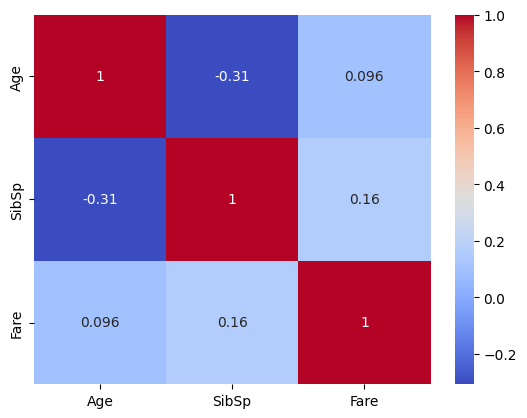

In [26]:
# explore data analysis
num_features = [ 'Age', 'SibSp', 'Fare']
cat_features = ['Pclass', 'Sex', 'Embarked']
p = data[num_features].corr()
sns.heatmap(p, annot=True, cmap="coolwarm")
plt.show()

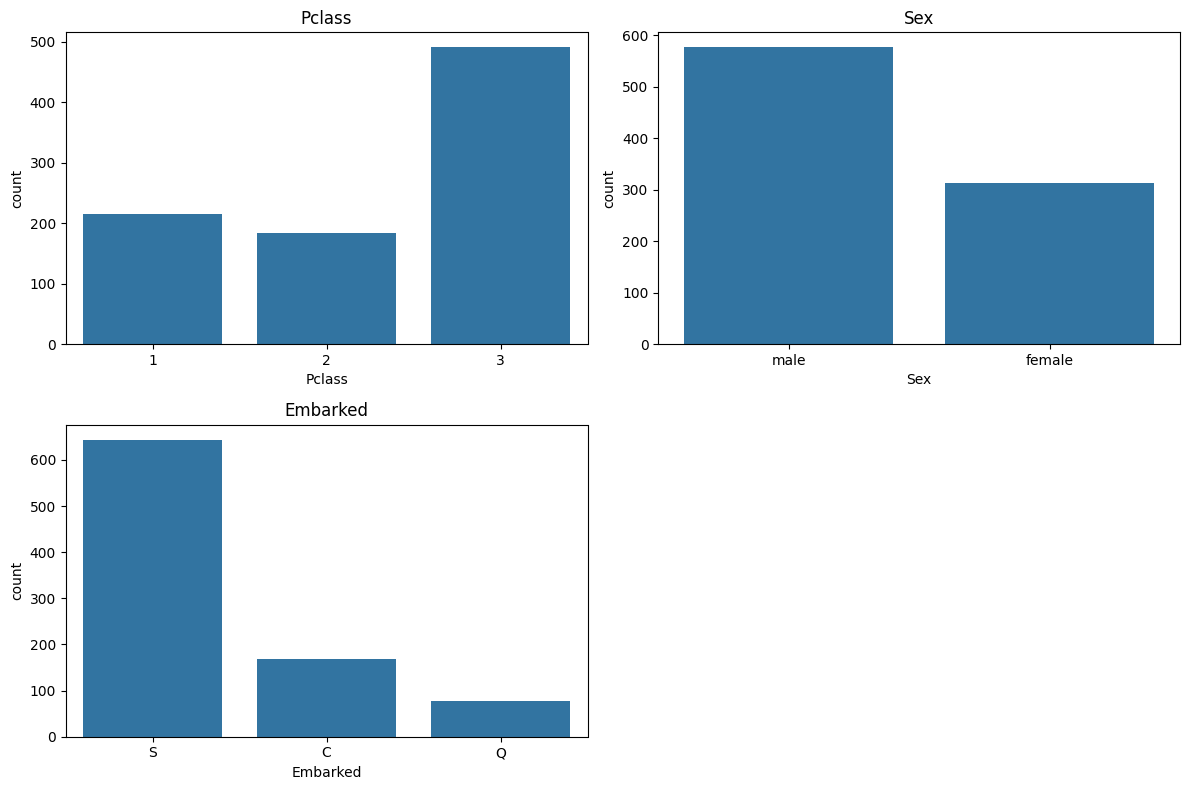

In [27]:
plt.figure(figsize=(12,8))

for i, col in enumerate(cat_features):
    plt.subplot(2,2,i+1)
    sns.countplot(data=data, x=col)
    plt.title(col)

plt.tight_layout()
plt.show()

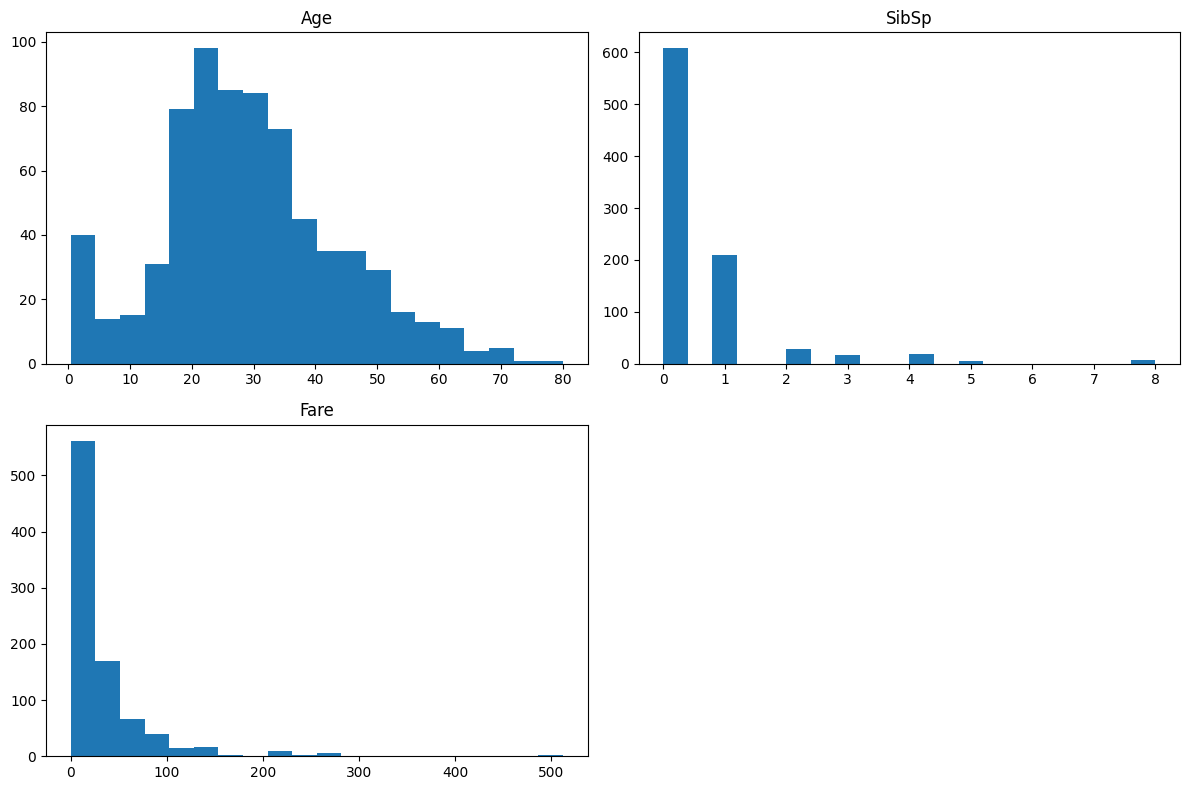

In [28]:
plt.figure(figsize=(12,8))
for i, feat in enumerate(num_features):
    plt.subplot(2,2, i+1)
    plt.hist(data[feat], bins=20)
    plt.title(feat)
plt.tight_layout()
plt.show()

In [29]:
# feature engineering

def engineer_features(df, age_median=None, fare_median=None):
    df = df.copy()

    # extracted from Name, then bucketed
    df["Title"] = df["Name"].str.extract(r",\s*([^.]+)\.", expand=False).str.strip()
    title_map = {
        "Mr": "Mr", "Miss": "Miss", "Mrs": "Mrs", "Master": "Master",
        "Dr": "Officer", "Rev": "Officer", "Col": "Officer", "Major": "Officer",
        "Capt": "Officer", "Jonkheer": "Royalty", "Don": "Royalty",
        "Sir": "Royalty", "the Countess": "Royalty", "Dona": "Royalty",
        "Lady": "Royalty", "Mlle": "Miss", "Ms": "Mrs", "Mme": "Mrs",
    }
    df["Title"] = df["Title"].map(title_map).fillna("Other")

    # FamilySize & IsAlone
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
    df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

    # first letter of Cabin
    df["Deck"] = df["Cabin"].str[0].fillna("U")

    # log-transform to reduce skew; fill missing with train median
    if fare_median is None:
        fare_median = df["Fare"].median()
    df["Fare"] = df["Fare"].fillna(fare_median)
    df["LogFare"] = np.log1p(df["Fare"])

    # fill missing with train median (passed in for test set)
    if age_median is None:
        age_median = df["Age"].median()
    df["Age"] = df["Age"].fillna(age_median)

    # discretise into 5 equal-width bins
    df["AgeBin"] = pd.cut(df["Age"], bins=5, labels=False)

    return df, age_median, fare_median

train_eng, age_med, fare_med = engineer_features(data)
test_eng, _, _               = engineer_features(test_data, age_median=age_med, fare_median=fare_med)

print("New features:", ["Title", "FamilySize", "IsAlone", "Deck", "LogFare", "AgeBin"])
train_eng[["Title", "FamilySize", "IsAlone", "Deck", "LogFare", "AgeBin"]].head()

New features: ['Title', 'FamilySize', 'IsAlone', 'Deck', 'LogFare', 'AgeBin']


,Title,FamilySize,IsAlone,Deck,LogFare,AgeBin
0,Mr,2,0,U,2.110213,1
1,Mrs,2,0,C,4.280593,2
2,Miss,1,1,U,2.188856,1
3,Mrs,2,0,C,3.990834,2
4,Mr,1,1,U,2.202765,2


In [30]:
# encode and scale

num_features = ["Age", "LogFare", "FamilySize", "AgeBin", "SibSp", "Parch"]
cat_features  = ["Pclass", "Sex", "Embarked", "Title", "Deck", "IsAlone"]

def encode(train_df, test_df, cat_cols):
    """Fit LabelEncoder on train only, then transform both — no leakage."""
    for col in cat_cols:
        le = LabelEncoder()
        train_df[col] = le.fit_transform(train_df[col].astype(str))
        known = set(le.classes_)
        test_df[col] = test_df[col].astype(str).apply(
            lambda x: le.transform([x])[0] if x in known else -1
        )
    return train_df, test_df

train_enc = train_eng.copy()
test_enc  = test_eng.copy()
train_enc, test_enc = encode(train_enc, test_enc, cat_features)

X_train = train_enc[num_features + cat_features]
y_train = data["Survived"]
X_test  = test_enc[num_features + cat_features]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only
X_test_scaled  = scaler.transform(X_test)

print("X_train shape:", X_train_scaled.shape)
print("Features:", num_features + cat_features)

X_train shape: (891, 12)
Features: ['Age', 'LogFare', 'FamilySize', 'AgeBin', 'SibSp', 'Parch', 'Pclass', 'Sex', 'Embarked', 'Title', 'Deck', 'IsAlone']


In [31]:
X_test.isna().sum()

Age           0
LogFare       0
FamilySize    0
AgeBin        0
SibSp         0
Parch         0
Pclass        0
Sex           0
Embarked      0
Title         0
Deck          0
IsAlone       0
dtype: int64

In [32]:
X_test["LogFare"] = X_test["LogFare"].fillna(X_train["LogFare"].median())
X_test["Age"] = X_test["Age"].fillna(X_train["Age"].median())
X_test.isna().sum()

/var/folders/rz/fvk6cxmn2z7378xj3p__c7580000gn/T/ipykernel_44326/3823213877.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test["LogFare"] = X_test["LogFare"].fillna(X_train["LogFare"].median())
/var/folders/rz/fvk6cxmn2z7378xj3p__c7580000gn/T/ipykernel_44326/3823213877.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test["Age"] = X_test["Age"].fillna(X_train["Age"].median())


Age           0
LogFare       0
FamilySize    0
AgeBin        0
SibSp         0
Parch         0
Pclass        0
Sex           0
Embarked      0
Title         0
Deck          0
IsAlone       0
dtype: int64

In [33]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(X_train.isna().sum())
print(np.isinf(X_train.values).sum())
print(X_train_scaled.min(), X_train_scaled.max())

Age           0
LogFare       0
FamilySize    0
AgeBin        0
SibSp         0
Parch         0
Pclass        0
Sex           0
Embarked      0
Title         0
Deck          0
IsAlone       0
dtype: int64
0
-3.0585777291682934 6.974147318082627


In [34]:
# Use cross-validation on the training set 
import warnings

from sklearn.model_selection import GridSearchCV
warnings.filterwarnings("ignore", category=RuntimeWarning)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    "C": [0.001, 0.01, 0.05, 0.1, 0.5, 1, 10],
    "solver": ["lbfgs", "liblinear", "newton-cg", "newton-cholesky", "sag", "saga"]
}
base_model = LogisticRegression(max_iter=1000)

grid_search = GridSearchCV(base_model, param_grid, cv=cv, scoring="accuracy")
grid_search.fit(X_train_scaled, y_train)

results = pd.DataFrame(grid_search.cv_results_)[["param_C", "mean_test_score", "std_test_score"]]
print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best mean CV accuracy: {grid_search.best_score_:.4f}")


Best parameters: {'C': 0.5, 'solver': 'liblinear'}
Best mean CV accuracy: 0.8002


In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42)

param_grid_rf = {
    "n_estimators": [100, 200, 500],
    "max_depth": [3, 5, 8, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

rf_grid = GridSearchCV(rf, param_grid_rf, cv=cv, scoring="accuracy", n_jobs=-1)

rf_grid.fit(X_train, y_train)

print("Best parameters:", rf_grid.best_params_)
print("Best CV accuracy:", rf_grid.best_score_)

Best parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Best CV accuracy: 0.8395016006528154


In [36]:
logistic_score = grid_search.best_score_
rf_score = rf_grid.best_score_

print("Logistic Regression:", logistic_score)
print("Random Forest:", rf_score)

Logistic Regression: 0.8002322515849603
Random Forest: 0.8395016006528154


In [37]:
# using the best model found above 

model = grid_search.best_estimator_

y_pred = model.predict(X_test_scaled)

submission = pd.DataFrame({
    "PassengerId": test_data["PassengerId"],
    "Survived": y_pred
})

submission.to_csv("y_pred.csv", index=False)


In [38]:
best_rf = rf_grid.best_estimator_

y_pred_rf = best_rf.predict(X_test)

submission_rf = pd.DataFrame({
    "PassengerId": test_data["PassengerId"],
    "Survived": y_pred_rf
})

submission_rf.to_csv("submission_rf.csv", index=False)

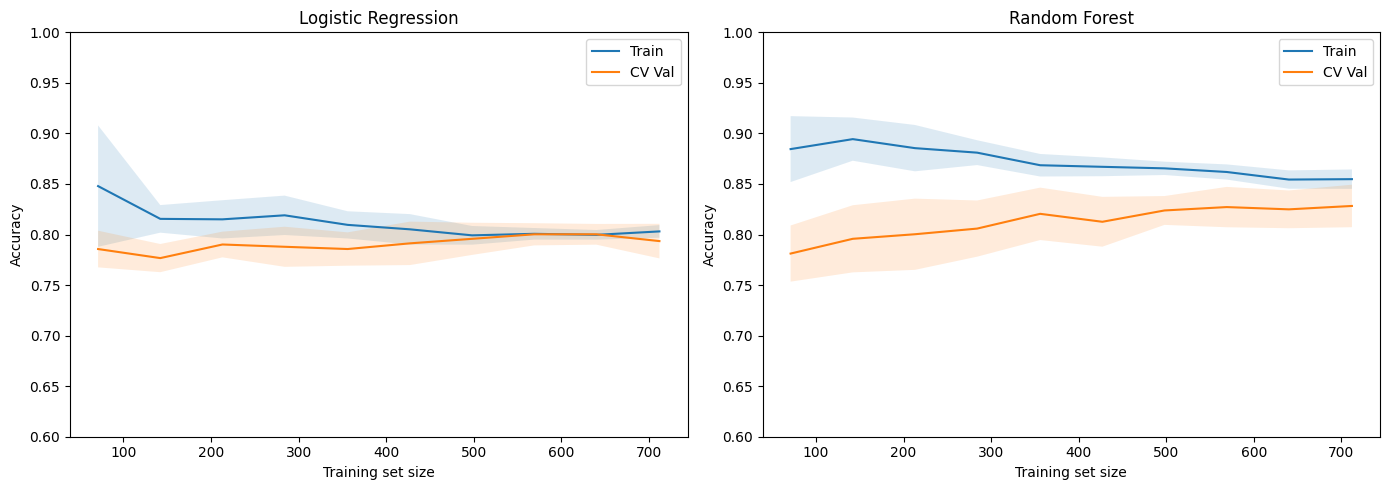

In [39]:
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = {
    "Logistic Regression": grid_search.best_estimator_,
    "Random Forest": rf_grid.best_estimator_,
}

for ax, (name, model) in zip(axes, models.items()):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train_scaled, y_train,
        cv=5, scoring="accuracy",
        train_sizes=np.linspace(0.1, 1.0, 10),
        shuffle=True, random_state=42
    )
    train_mean = train_scores.mean(axis=1)
    val_mean   = val_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_std    = val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, label="Train")
    ax.plot(train_sizes, val_mean,   label="CV Val")
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15)
    ax.fill_between(train_sizes, val_mean   - val_std,   val_mean   + val_std,   alpha=0.15)
    ax.set_title(name)
    ax.set_xlabel("Training set size")
    ax.set_ylabel("Accuracy")
    ax.legend()
    ax.set_ylim(0.6, 1.0)

plt.tight_layout()
plt.show()